# Part a

In [1]:
"""Classical Hodgkin-Huxley model under constant current injection.

Python port of hh_sim.m. Same parameters, same shifted potential
convention of the 1952 papers, so rest is near V = 0 and the spike peak
near V = 100.

Call it and capture what you need:
    t, V, spk, rate = hh_sim()

Running the file directly (python hh_sim.py) prints the spike count and
rate at the default Id = 7. There is no MATLAB-style ans here, but t is
30001 elements of 0 to 300 in steps of 0.01, so avoid echoing the whole
return value in a notebook cell.

Regression checks with default parameters:
    Id = 7 gives sustained firing at 58.3 Hz
    Id = 5 gives no sustained firing
The 58.3 is solver independent: BDF, LSODA, Radau and RK45 all agree to
three digits, so a port that lands more than a Hz away has a real bug,
most likely a sign in an exponent. The removable singularities in
alpha_m and alpha_n at V = 25 and V = 10 are patched below; if you
rewrite them, check that alpha_m(25) and alpha_n(10) come out finite.

The reported rheobase depends on how you define repetitive firing: both
skipfrac and the spike count you demand of it will move the answer,
because the underlying bifurcation is subcritical. State the criterion
you used rather than treating the number as absolute.
"""
import numpy as np
from scipy.integrate import solve_ivp
__all__ = ["hh_sim"]

# ---- gating rate functions (ms^-1), with removable singularities patched ----
def _am(V):
    return 1.0 if abs(V - 25) < 1e-6 else 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)

def _bm(V):
    return 4 * np.exp(-V / 18)

def _ah(V):
    return 0.07 * np.exp(-V / 20)

def _bh(V):
    return 1 / (np.exp((30 - V) / 10) + 1)

def _an(V):
    return 0.1 if abs(V - 10) < 1e-6 else 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)

def _bn(V):
    return 0.125 * np.exp(-V / 80)

def hh_sim(Id = 7.0, tmax = 300.0, gK = 36.0, gNa = 120.0, skipfrac = 0.4):
    """Integrate the HH model under constant current.
    Parameters
    ----------
    Id : injected current density (uA/cm^2). Defaults to 7, above
         rheobase, so hh_sim() with no arguments gives repetitive
         firing.
    tmax : simulation duration (ms).
    gK, gNa : maximal conductances (mS/cm^2).
    skipfrac : fraction of the trace discarded before counting spikes, so
         that the onset transient is not mistaken for repetitive firing.

    Returns
    -------
    t, V : time vector (ms) and voltage trace (mV).
    spk : spike times, upward crossings of 40 mV.
    rate : mean firing rate in Hz over the counted window, 0 if fewer
           than two spikes.
    """
    C, gL, ENa, EK, EL = 1.0, 0.3, 115.0, -12.0, 10.6

    def rhs(_, y):
        V, m, h, n = y
        INa = gNa * m**3 * h * (V - ENa)
        IK = gK * n**4 * (V - EK)
        IL = gL * (V - EL)
        return [
            (Id - INa - IK - IL) / C,
            _am(V) * (1 - m) - _bm(V) * m,
            _ah(V) * (1 - h) - _bh(V) * h,
            _an(V) * (1 - n) - _bn(V) * n,
        ]

    V0 = 0.0 # steady state gating at rest
    y0 = [
        V0,
        _am(V0) / (_am(V0) + _bm(V0)),
        _ah(V0) / (_ah(V0) + _bh(V0)),
        _an(V0) / (_an(V0) + _bn(V0)),
    ]

    t = np.arange(0, tmax + 1e-9, 0.01)
    sol = solve_ivp(rhs, [0, tmax], y0, method = "BDF", t_eval = t,
                    rtol = 1e-8, atol = 1e-10, max_step = 0.05)
    V = sol.y[0]

    i0 = max(1, int(round(skipfrac * len(t))))
    up = np.flatnonzero((V[i0:-1] < 40) & (V[i0 + 1:] >= 40)) + i0
    spk = t[up]

    rate = 1000 * (len(spk) - 1) / (spk[-1] - spk[0]) if len(spk) >= 2 else 0.0
    return t, V, spk, rate

In [2]:
def fires(Id, gK = 36.0, nmin = 2):
    """Criterion: >= nmin spikes in the post-skip window of hh_sim."""
    _, _, spk, _ = hh_sim(Id = Id, gK = gK)
    return len(spk) >= nmin

def bisect(lo, hi, gK = 36.0, tol = 5e-4):
    while hi - lo > tol:
        mid = (lo + hi) / 2
        if fires(mid, gK = gK): hi = mid
        else: lo = mid
    return mid

rheobase = bisect(5.0, 7.0)
print(f"rheobase (300ms, nmin=2) = {rheobase:.3f}")

rheobase (300ms, nmin=2) = 6.256


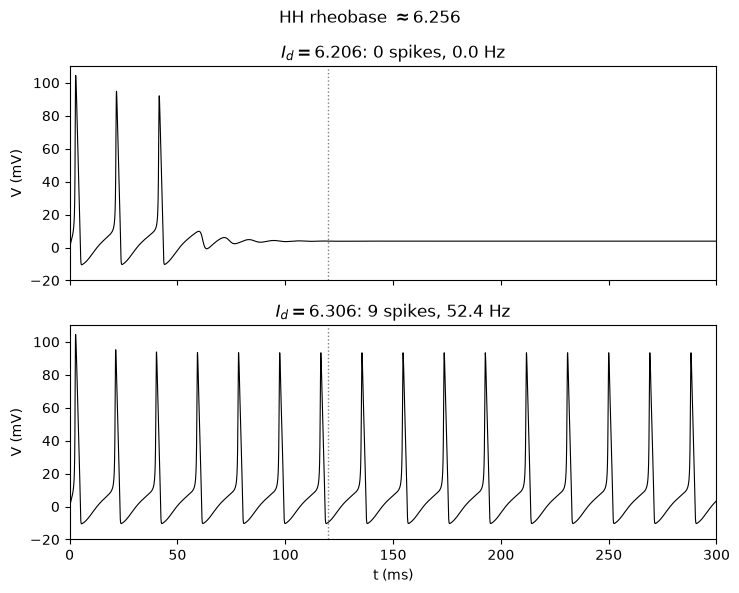

In [3]:
import matplotlib.pyplot as plt
eps = 0.05
fig, axs = plt.subplots(2, 1, figsize = (7.5, 6), sharex = True, sharey = True)
for ax, dI in zip(axs, (-eps, +eps)):
    t, V, spk, rate = hh_sim(Id = rheobase + dI)
    ax.plot(t, V, "k", lw = 0.8)
    ax.axvline(120, color = "gray", ls = ":", lw = 1)
    ax.set_title(f"$I_d = {rheobase + dI:.3f}$: {len(spk)} spikes, {rate:.1f} Hz")
    ax.set_ylabel("V (mV)")

axs[0].set_ylim(-20, 110)        
axs[1].set_xlim(0, 300)
axs[1].set_xlabel("t (ms)")
fig.suptitle(f"HH rheobase $\\approx {rheobase:.3f}$")

fig.tight_layout()
plt.show()

# Part (b)

In [4]:
Is = np.linspace(rheobase + 0.05, 2 * rheobase, 20)
rates = []
for Id in Is:
    t, V, spk, rate = hh_sim(Id = Id)
    rates.append(rate)
    print(f"I = {Id:6.3f}   spikes = {len(spk):3d}   rate = {rate:7.3f} Hz")

rates = np.array(rates)

I =  6.306   spikes =   9   rate =  52.432 Hz
I =  6.633   spikes =  10   rate =  56.099 Hz
I =  6.960   spikes =  11   rate =  58.096 Hz
I =  7.286   spikes =  10   rate =  59.674 Hz
I =  7.613   spikes =  11   rate =  61.024 Hz
I =  7.940   spikes =  11   rate =  62.243 Hz
I =  8.266   spikes =  11   rate =  63.359 Hz
I =  8.593   spikes =  12   rate =  64.403 Hz
I =  8.920   spikes =  12   rate =  65.383 Hz
I =  9.246   spikes =  12   rate =  66.317 Hz
I =  9.573   spikes =  13   rate =  67.204 Hz
I =  9.899   spikes =  12   rate =  68.057 Hz
I = 10.226   spikes =  12   rate =  68.879 Hz
I = 10.553   spikes =  12   rate =  69.669 Hz
I = 10.879   spikes =  12   rate =  70.441 Hz
I = 11.206   spikes =  13   rate =  71.183 Hz
I = 11.533   spikes =  13   rate =  71.908 Hz
I = 11.859   spikes =  13   rate =  72.613 Hz
I = 12.186   spikes =  13   rate =  73.300 Hz
I = 12.513   spikes =  14   rate =  73.973 Hz


<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_32610/1434200706.py:4: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$I_d$ $\\left(\\frac{\mu A}{\\text{cm}^2}\\right)$")


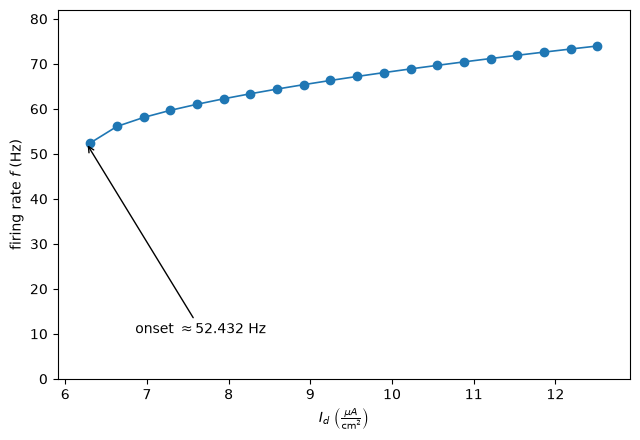

In [5]:
fig, ax = plt.subplots(figsize = (6.5, 4.5))
ax.plot(Is, rates, "o-", lw = 1.2)
ax.annotate(f"onset $\\approx {rates[0]:.3f}$ Hz", xy = (rheobase, rates[0]), xytext = (rheobase + 0.6, 10), arrowprops = dict(arrowstyle = "->"))
ax.set_xlabel("$I_d$ $\\left(\\frac{\mu A}{\\text{cm}^2}\\right)$")
ax.set_ylabel("firing rate $f$ (Hz)")
ax.set_xlim(min(Is) - 0.4, max(Is) + 0.4)
ax.set_ylim(0, rates.max() + 8)

fig.tight_layout()
plt.show()

# Part (c)

In [6]:
rheobase_lower_gK = bisect(5.0, 7.0, gK = 30.0)
print(f"rheobase (300ms, nmin=2, gK=30.0) = {rheobase_lower_gK:.3f}")

rheobase (300ms, nmin=2, gK=30.0) = 5.000


In [7]:
rates_lower_gK = []
for Id in Is:
    t, V, spk, rate = hh_sim(Id = Id, gK = 30.0)
    rates_lower_gK.append(rate)
    print(f"I = {Id:6.3f}   spikes = {len(spk):3d}   rate = {rate:7.3f} Hz")

rates_lower_gK = np.array(rates_lower_gK)

I =  6.306   spikes =  12   rate =  65.332 Hz
I =  6.633   spikes =  12   rate =  66.317 Hz
I =  6.960   spikes =  13   rate =  67.268 Hz
I =  7.286   spikes =  12   rate =  68.187 Hz
I =  7.613   spikes =  12   rate =  69.074 Hz
I =  7.940   spikes =  12   rate =  69.930 Hz
I =  8.266   spikes =  13   rate =  70.767 Hz
I =  8.593   spikes =  13   rate =  71.578 Hz
I =  8.920   spikes =  13   rate =  72.368 Hz
I =  9.246   spikes =  13   rate =  73.140 Hz
I =  9.573   spikes =  14   rate =  73.893 Hz
I =  9.899   spikes =  14   rate =  74.627 Hz
I = 10.226   spikes =  14   rate =  75.345 Hz
I = 10.553   spikes =  14   rate =  76.046 Hz
I = 10.879   spikes =  13   rate =  76.736 Hz
I = 11.206   spikes =  14   rate =  77.413 Hz
I = 11.533   spikes =  14   rate =  78.078 Hz
I = 11.859   spikes =  14   rate =  78.726 Hz
I = 12.186   spikes =  14   rate =  79.365 Hz
I = 12.513   spikes =  14   rate =  80.000 Hz


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_32610/3236610592.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$I_d$ $\\left(\\frac{\mu A}{\\text{cm}^2}\\right)$")


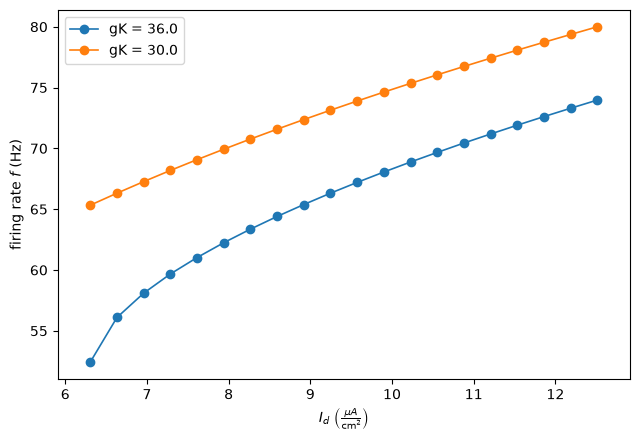

In [8]:
fig, ax = plt.subplots(figsize = (6.5, 4.5))
ax.plot(Is, rates, "o-", lw = 1.2, label = "gK = 36.0")
ax.plot(Is, rates_lower_gK, "o-", lw = 1.2, label = "gK = 30.0")

ax.legend()
ax.set_xlabel("$I_d$ $\\left(\\frac{\mu A}{\\text{cm}^2}\\right)$")
ax.set_ylabel("firing rate $f$ (Hz)")
ax.set_xlim(min(Is) - 0.4, max(Is) + 0.4)

fig.tight_layout()
plt.show()